In [1]:
import pandas as pd
import numpy as np
import joblib
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
risk_results = pd.read_csv(
    "../data/processed/risk_results.csv"
)

print("Risk results loaded successfully.")
print("Shape:", risk_results.shape)

Risk results loaded successfully.
Shape: (4670, 177)


In [3]:
risk_results.head()

,interval_start,equipment_ID,count_sum,A_028,A_029,A_024,A_045,A_001,A_058,A_064,...,downtime_change,performance_change,health_score,future_production,future_downtime,future_performance_loss,future_risk,risk_prediction,risk_probability,risk_level
0,2021-09-29 10:00:00,s_2,3,0.0,0,0,0.0,1.0,0.0,NaN,...,-0.366543,0.009372,99.102540,0.150878,0.053570,0.055742,0,1,61.150925,HIGH
1,2021-09-29 10:00:00,s_5,1,NaN,0,0,0.0,NaN,NaN,NaN,...,0.017514,0.001534,99.923643,0.965107,0.008346,0.025134,0,0,48.113310,MEDIUM
2,2021-09-29 11:00:00,s_5,3,NaN,0,0,0.0,NaN,NaN,NaN,...,0.028751,0.169927,99.671297,0.109639,0.046931,0.084325,0,0,45.625343,MEDIUM
3,2021-09-29 11:00:00,s_3,3,0.0,0,0,0.0,2.0,0.0,0.0,...,0.024945,-0.025711,99.802793,0.994341,0.005659,0.000000,0,0,45.030220,MEDIUM
4,2021-09-29 12:00:00,s_3,3,0.0,0,0,0.0,1.0,0.0,0.0,...,0.166011,-0.033187,99.698141,0.840986,0.115300,0.040675,0,1,50.587630,MEDIUM


In [4]:
print("Actual Risk:")
print(
    risk_results["future_risk"].value_counts()
)

print("\nPredicted Risk:")
print(
    risk_results["risk_prediction"].value_counts()
)

Actual Risk:
future_risk
0    3693
1     977
Name: count, dtype: int64

Predicted Risk:
risk_prediction
0    2990
1    1680
Name: count, dtype: int64


In [5]:
y_true = risk_results["future_risk"]

y_pred = risk_results["risk_prediction"]

y_probability = (
    risk_results["risk_probability"] / 100
)

print("Evaluation variables created.")

Evaluation variables created.


In [6]:
accuracy = accuracy_score(
    y_true,
    y_pred
)

print(
    "Accuracy:",
    round(accuracy, 4)
)

Accuracy: 0.6028


In [7]:
print(
    "Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

Accuracy: 60.28 %


In [8]:
precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

print(
    "Precision:",
    round(precision, 4)
)

Precision: 0.2387


In [9]:
recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

print(
    "Recall:",
    round(recall, 4)
)

Recall: 0.4104


In [10]:
f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

print(
    "F1 Score:",
    round(f1, 4)
)

F1 Score: 0.3018


In [11]:
if y_true.nunique() == 2:

    roc_auc = roc_auc_score(
        y_true,
        y_probability
    )

    print(
        "ROC-AUC:",
        round(roc_auc, 4)
    )

else:

    roc_auc = np.nan

    print(
        "ROC-AUC cannot be calculated because "
        "test data contains only one class."
    )

ROC-AUC: 0.5447


In [12]:
if y_true.nunique() == 2:

    pr_auc = average_precision_score(
        y_true,
        y_probability
    )

    print(
        "PR-AUC:",
        round(pr_auc, 4)
    )

else:

    pr_auc = np.nan

    print(
        "PR-AUC cannot be calculated."
    )

PR-AUC: 0.236


In [13]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Normal",
            "Risk"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Normal       0.81      0.65      0.72      3693
        Risk       0.24      0.41      0.30       977

    accuracy                           0.60      4670
   macro avg       0.52      0.53      0.51      4670
weighted avg       0.69      0.60      0.63      4670



In [14]:
cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[2414 1279]
 [ 576  401]]


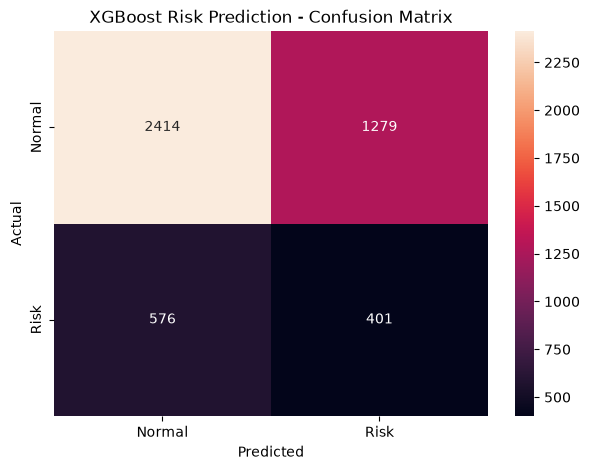

In [15]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Normal", "Risk"],
    yticklabels=["Normal", "Risk"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Risk Prediction - Confusion Matrix")

plt.show()

In [16]:
tn, fp, fn, tp = cm.ravel()

print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)

True Negative : 2414
False Positive: 1279
False Negative: 576
True Positive : 401


In [17]:
if (fn + tp) > 0:

    false_negative_rate = (
        fn / (fn + tp)
    )

else:

    false_negative_rate = 0

print(
    "False Negative Rate:",
    round(
        false_negative_rate * 100,
        2
    ),
    "%"
)

False Negative Rate: 58.96 %


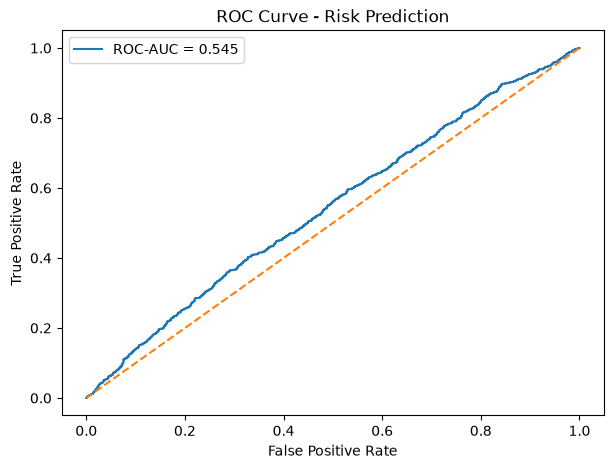

In [18]:
if y_true.nunique() == 2:

    fpr, tpr, thresholds = roc_curve(
        y_true,
        y_probability
    )

    plt.figure(figsize=(7, 5))

    plt.plot(
        fpr,
        tpr,
        label=f"ROC-AUC = {roc_auc:.3f}"
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - Risk Prediction")
    plt.legend()

    plt.show()

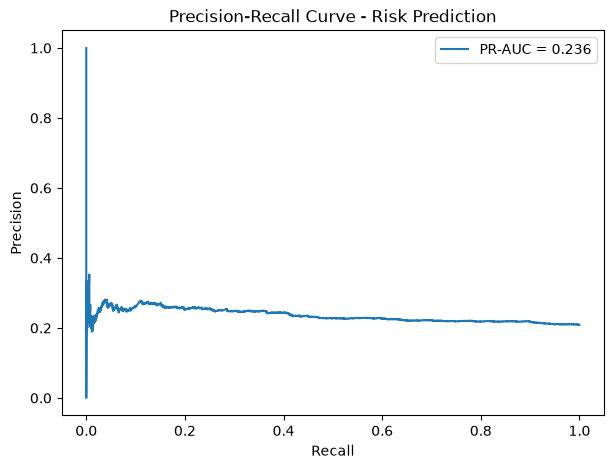

In [19]:
if y_true.nunique() == 2:

    precision_values, recall_values, pr_thresholds = (
        precision_recall_curve(
            y_true,
            y_probability
        )
    )

    plt.figure(figsize=(7, 5))

    plt.plot(
        recall_values,
        precision_values,
        label=f"PR-AUC = {pr_auc:.3f}"
    )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(
        "Precision-Recall Curve - Risk Prediction"
    )

    plt.legend()

    plt.show()

In [20]:
model_data = joblib.load(
    "../models/risk_model.pkl"
)

risk_model = model_data["model"]

features = model_data["features"]

print("Risk model loaded successfully.")

print("\nFeatures used:")
print(features)

Risk model loaded successfully.

Features used:
['%production', '%downtime', '%idle', '%performance_loss', '%scheduled_downtime', '#changes', 'production_rolling_6h', 'downtime_rolling_6h', 'production_change', 'downtime_change', 'performance_change', 'health_score']


In [21]:
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": (
        risk_model.feature_importances_
    )
})

feature_importance = (
    feature_importance
    .sort_values(
        "importance",
        ascending=False
    )
)

feature_importance

,feature,importance
6,production_rolling_6h,0.099574
11,health_score,0.085305
3,%performance_loss,0.085063
4,%scheduled_downtime,0.084964
9,downtime_change,0.083537
0,%production,0.083155
2,%idle,0.083005
8,production_change,0.082564
7,downtime_rolling_6h,0.081915
10,performance_change,0.079901


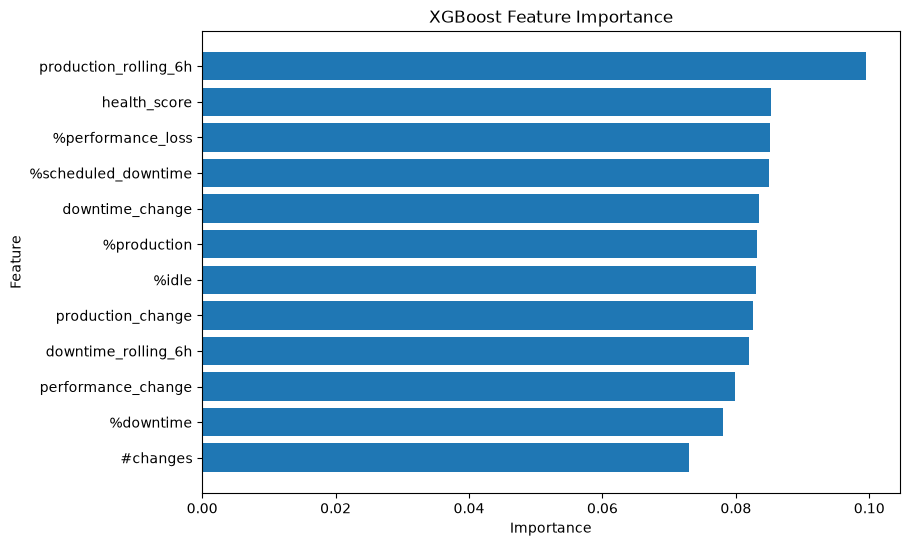

In [22]:
plt.figure(figsize=(9, 6))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(
    "XGBoost Feature Importance"
)

plt.gca().invert_yaxis()

plt.show()

In [23]:
evaluation_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC",
        "False Negative Rate"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        pr_auc,
        false_negative_rate
    ]
})

evaluation_summary

,Metric,Score
0,Accuracy,0.602784
1,Precision,0.238690
2,Recall,0.410440
3,F1 Score,0.301844
4,ROC-AUC,0.544729
5,PR-AUC,0.236050
6,False Negative Rate,0.589560


In [24]:
evaluation_summary["Percentage"] = (
    evaluation_summary["Score"] * 100
).round(2)

evaluation_summary

,Metric,Score,Percentage
0,Accuracy,0.602784,60.28
1,Precision,0.238690,23.87
2,Recall,0.410440,41.04
3,F1 Score,0.301844,30.18
4,ROC-AUC,0.544729,54.47
5,PR-AUC,0.236050,23.60
6,False Negative Rate,0.589560,58.96


In [25]:
os.makedirs(
    "../data/processed",
    exist_ok=True
)

In [26]:
evaluation_summary.to_csv(
    "../data/processed/model_metrics.csv",
    index=False
)

print(
    "Model metrics saved successfully."
)

Model metrics saved successfully.


In [27]:
feature_importance.to_csv(
    "../data/processed/risk_feature_importance.csv",
    index=False
)

print(
    "Feature importance saved successfully."
)

Feature importance saved successfully.


In [28]:
confusion_matrix_df = pd.DataFrame(
    cm,
    index=["Actual Normal", "Actual Risk"],
    columns=["Predicted Normal", "Predicted Risk"]
)

confusion_matrix_df.to_csv(
    "../data/processed/confusion_matrix.csv"
)

print(
    "Confusion matrix saved successfully."
)

Confusion matrix saved successfully.


In [29]:
print("=" * 50)
print("MODEL EVALUATION SUMMARY")
print("=" * 50)

print(
    f"Accuracy          : {accuracy * 100:.2f}%"
)

print(
    f"Precision         : {precision * 100:.2f}%"
)

print(
    f"Recall            : {recall * 100:.2f}%"
)

print(
    f"F1 Score          : {f1 * 100:.2f}%"
)

if not np.isnan(roc_auc):
    print(
        f"ROC-AUC           : {roc_auc:.4f}"
    )

if not np.isnan(pr_auc):
    print(
        f"PR-AUC            : {pr_auc:.4f}"
    )

print(
    f"False Negative Rate: "
    f"{false_negative_rate * 100:.2f}%"
)

print("=" * 50)

MODEL EVALUATION SUMMARY
Accuracy          : 60.28%
Precision         : 23.87%
Recall            : 41.04%
F1 Score          : 30.18%
ROC-AUC           : 0.5447
PR-AUC            : 0.2360
False Negative Rate: 58.96%
